<a href="https://colab.research.google.com/github/saifulroni/clusters_data/blob/main/clustering_framingham_processed_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-Means Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans

In [ ]:
url = 'https://raw.githubusercontent.com/muajnstu/Large_Scale_Implementation_of_DSK_Chain/refs/heads/main/Cleaned_Data/framingham_processed.csv'
df = pd.read_csv(url)
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
X = df.drop(columns=['TenYearCHD'])
y = df['TenYearCHD']

X_0 = X[y == 0]
X_1 = X[y == 1]

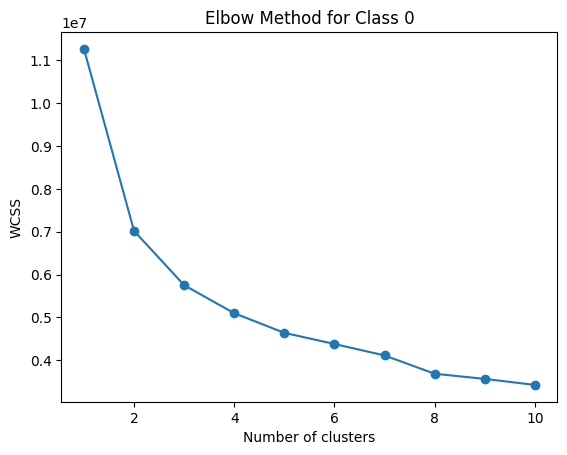

In [ ]:
wcss_0 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_0)
    wcss_0.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_0, marker='o')
plt.title('Elbow Method for Class 0')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

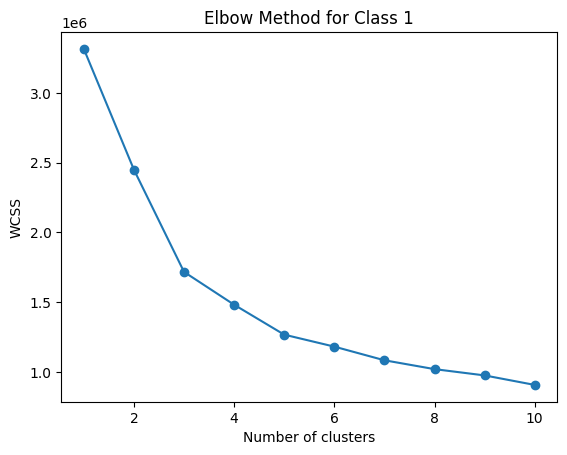

In [ ]:
wcss_1 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_1)
    wcss_1.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_1, marker='o')
plt.title('Elbow Method for Class 1')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
n_clusters_0 = 2   # <-- set based on elbow visualization
n_clusters_1 = 3   # <-- set based on elbow visualization

kmeans_0 = KMeans(n_clusters=n_clusters_0, random_state=42)
sub_labels_0 = kmeans_0.fit_predict(X_0)

kmeans_1 = KMeans(n_clusters=n_clusters_1, random_state=42)
sub_labels_1 = kmeans_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 1527 samples
Class 0 - Cluster 1: 2067 samples


In [ ]:
counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 1 - Cluster 0: 366 samples
Class 1 - Cluster 1: 21 samples
Class 1 - Cluster 2: 257 samples


DBSCAN

In [ ]:
dbscan_0 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_0 = dbscan_0.fit_predict(X_0)

dbscan_1 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_1 = dbscan_1.fit_predict(X_1)

In [ ]:
unique_0, counts_0 = np.unique(sub_labels_0, return_counts=True)
for cluster, count in zip(unique_0, counts_0):
    print(f"Class 0 - Cluster {cluster}: {count} samples")

Class 0 - Cluster -1: 3594 samples


In [ ]:
unique_1, counts_1 = np.unique(sub_labels_1, return_counts=True)
for cluster, count in zip(unique_1, counts_1):
    print(f"Class 1 - Cluster {cluster}: {count} samples")

Class 1 - Cluster -1: 644 samples


Hierarchical Clustering

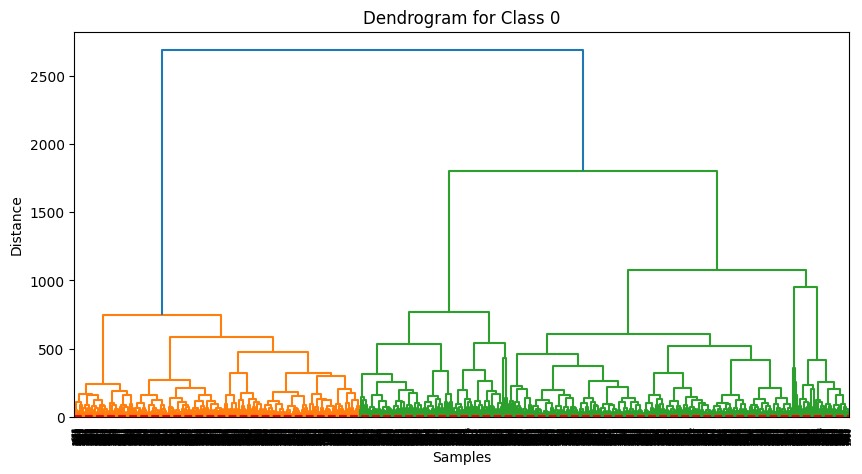

In [ ]:
# Generate linkage matrix for Class 0
Z = linkage(X_0, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 0")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_0, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 1


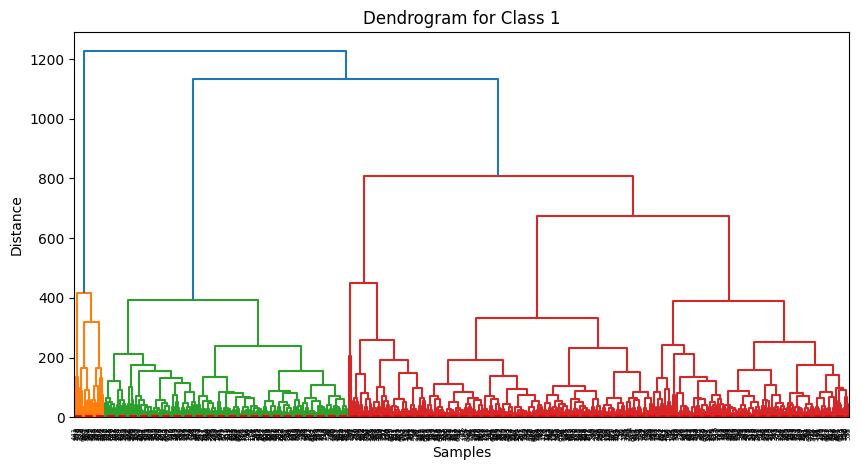

In [ ]:
# Generate linkage matrix for Class 1
Z = linkage(X_1, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 1")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_1, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 1


second method

In [ ]:
hc_0 = AgglomerativeClustering(n_clusters=2, linkage='average')
sub_labels_0 = hc_0.fit_predict(X_0)

hc_1 = AgglomerativeClustering(n_clusters=2, linkage='average')
sub_labels_1 = hc_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 3593 samples
Class 0 - Cluster 1: 1 samples
Class 1 - Cluster 0: 640 samples
Class 1 - Cluster 1: 4 samples


Spectral Clustering

In [ ]:
def run_spectral_clustering(X_data, class_label):
    best_score = -1
    best_k = None
    best_labels = None

    # Search for the best number of clusters
    for k in range(2, 7):
        sc = SpectralClustering(
            n_clusters=k,
            affinity='nearest_neighbors',  # or 'rbf'
            assign_labels='kmeans',
            random_state=42
        )
        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels)
        print(f"Class {class_label} | n_clusters={k}, Silhouette Score={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"Best n_clusters for Class {class_label}: {best_k} (Silhouette Score={best_score:.4f})")
    return best_labels, best_k, best_score

In [ ]:
# ---- Run Spectral Clustering with automatic k selection ----
sub_labels_0, best_k_0, best_score_0 = run_spectral_clustering(X_0, class_label=0)
sub_labels_1, best_k_1, best_score_1 = run_spectral_clustering(X_1, class_label=1)

Class 0 | n_clusters=2, Silhouette Score=0.3230
Class 0 | n_clusters=3, Silhouette Score=0.2433
Class 0 | n_clusters=4, Silhouette Score=0.2259
Class 0 | n_clusters=5, Silhouette Score=0.1955
Class 0 | n_clusters=6, Silhouette Score=0.2057
Best n_clusters for Class 0: 2 (Silhouette Score=0.3230)
Class 1 | n_clusters=2, Silhouette Score=0.2812
Class 1 | n_clusters=3, Silhouette Score=0.3058
Class 1 | n_clusters=4, Silhouette Score=0.2253
Class 1 | n_clusters=5, Silhouette Score=0.2168
Class 1 | n_clusters=6, Silhouette Score=0.1935
Best n_clusters for Class 1: 3 (Silhouette Score=0.3058)


In [ ]:
# Show cluster counts
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 1586 samples
Class 0 - Cluster 1: 2008 samples
Class 1 - Cluster 0: 370 samples
Class 1 - Cluster 1: 253 samples
Class 1 - Cluster 2: 21 samples


****MiniBatchKMeans

In [ ]:
n_clusters_0 = 2
mbk_0 = MiniBatchKMeans(
    n_clusters=n_clusters_0,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_0 = mbk_0.fit_predict(X_0)

n_clusters_1 = 3
mbk_1 = MiniBatchKMeans(
    n_clusters=n_clusters_1,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_1 = mbk_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 1871 samples
Class 0 - Cluster 1: 1723 samples
Class 1 - Cluster 0: 243 samples
Class 1 - Cluster 1: 380 samples
Class 1 - Cluster 2: 21 samples


In [ ]:
# Copy df_0 and assign cluster labels starting from 0
df_0 = X_0.copy()
df_0['TenYearCHD'] = 0
df_0['Cluster_Label'] = sub_labels_0.astype(int)  # starts from 0

# Copy df_1 and assign cluster labels continuing from the last cluster of df_0
df_1 = X_1.copy()
df_1['TenYearCHD'] = 1
offset = max(df_0['Cluster_Label']) + 1  # continue numbering from the next integer
df_1['Cluster_Label'] = (sub_labels_1 + offset).astype(int)  # continues from 0-based numbering

# Combine both dataframes
final_df = pd.concat([df_0, df_1], ignore_index=True)

# Drop the target column before saving
final_df = final_df.drop(columns=['TenYearCHD'])

# Save to CSV
final_df.to_csv('Clustered_framingham_processed.csv', index=False)
print("Saved as Clustered_framingham_processed.csv")


Saved as Clustered_framingham_processed.csv


In [ ]:
import pandas as pd

df_processed = pd.read_csv('Clustered_framingham_processed.csv')
display(df_processed.head())

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Cluster_Label
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,1
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,1
3,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,1
4,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,1


In [ ]:
import pandas as pd

# Load the Clustered_framingham_processed.csv DataFrame
df_to_rename = pd.read_csv('Clustered_framingham_processed.csv')

# Check if 'Cluster_Label' exists before attempting to rename
if 'Cluster_Label' in df_to_rename.columns:
    df_renamed = df_to_rename.rename(columns={'Cluster_Label': 'TenYearCHD'})
    output_filename = 'Clustered_framingham_with_TenYearCHD.csv'
    df_renamed.to_csv(output_filename, index=False)
    print(f"DataFrame with 'Cluster_Label' renamed to 'TenYearCHD' saved as {output_filename}")
    print("Updated DataFrame head:")
    print(df_renamed.head())
else:
    print("Error: 'Cluster_Label' column not found in the DataFrame. Cannot rename.")

DataFrame with 'Cluster_Label' renamed to 'TenYearCHD' saved as Clustered_framingham_with_TenYearCHD.csv
Updated DataFrame head:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   46        3.0              1        23.0     0.0                0   
4     0   43        2.0              0         0.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             0         0    285.0  130.0   84.0  23.10       85.0     85.0   
4

reclustering

In [ ]:
def run_spectral_clustering(X_data, class_label=None, forced_k=None, k_range=(2, 7)):
    """
    Run spectral clustering trying k in range(k_range) (k_range end exclusive).
    If forced_k is provided and in tested ks, returns labels for forced_k.
    Returns: labels (np.array, indexed like X_data), chosen_k, score_for_chosen_k, scores_dict
    """
    all_scores = {}
    best_k = None
    best_score = -np.inf
    best_labels = None

    ks = list(range(k_range[0], k_range[1]))
    for k in ks:
        sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels) if len(np.unique(labels)) > 1 else -1
        all_scores[k] = score
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
        print(f"[{class_label}] k={k} -> silhouette={score:.4f}")

    # If forced_k requested and valid, recompute labels for forced_k
    if forced_k is not None:
        if forced_k not in all_scores:
            raise ValueError(f"forced_k {forced_k} not in tested ks {ks}")
        print(f"[{class_label}] Using forced_k={forced_k} (silhouette={all_scores[forced_k]:.4f})")
        sc = SpectralClustering(n_clusters=forced_k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        forced_labels = sc.fit_predict(X_data)
        return forced_labels, forced_k, all_scores[forced_k], all_scores

    return best_labels, best_k, best_score, all_scores


def initial_cluster_by_class(X, y, k_range=(2,7)):
    """
    Cluster data separately for each distinct class in y.
    Returns dict: class_label -> pd.Series(labels, index = X_class.index)
    Also returns dicts for chosen k and scores.
    """
    labels_by_class = {}
    best_k_by_class = {}
    score_by_class = {}
    for cls in np.unique(y):
        X_cls = X[y == cls]
        labels, chosen_k, best_score, scores = run_spectral_clustering(X_cls, class_label=cls, k_range=k_range)
        labels_by_class[cls] = pd.Series(labels, index=X_cls.index)
        best_k_by_class[cls] = chosen_k
        score_by_class[cls] = best_score
    return labels_by_class, best_k_by_class, score_by_class


def get_cluster_counts(labels_by_class):
    """
    labels_by_class: dict from class_label -> pd.Series(labels, index=original indices)
    Returns nested dict: {class: {cluster_id: count, ...}, ...}
    """
    counts = {}
    for cls, ser in labels_by_class.items():
        vc = ser.value_counts().sort_index().to_dict()
        counts[cls] = vc
    return counts


def recluster_subset(X, y, labels_by_class, class_label, cluster_id, forced_k=None, k_range=(2,7)):
    """
    Recluster the subset corresponding to (class_label, cluster_id).
    Returns: sub_labels_series (pd.Series indexed same as subset), chosen_k, score
    Does NOT modify labels_by_class automatically; returns the new labels so caller can integrate.
    """
    # subset mask and X_subset
    mask = (y == class_label) & (labels_by_class[class_label] == cluster_id)
    X_subset = X.loc[mask]
    if X_subset.shape[0] < 2:
        raise ValueError("Subset has fewer than 2 samples; cannot recluster.")

    sub_labels, chosen_k, score, _ = run_spectral_clustering(X_subset, class_label=f"{class_label}-{cluster_id}",
                                                             forced_k=forced_k, k_range=k_range)
    return pd.Series(sub_labels, index=X_subset.index), chosen_k, score

def assemble_final_labels(X, y, labels_by_class, recluster_results=None):
    """
    Create a single Final_Cluster_Label column (int) for the full dataset.
    - labels_by_class: dict class -> pd.Series(original cluster labels)
    - recluster_results: dict with keys (class_label, cluster_id) -> pd.Series(sub_labels indexed like subset)
      If present, those samples will be assigned new sub-cluster ids (unique) instead of the original cluster id.
    Returns: final_labels (np.array aligned with X.index order), and mapping info
    """
    final_labels = np.full(len(X), -1, dtype=int)
    offset = 0
    mapping = {}

    # ensure series align to original indices
    for cls in sorted(labels_by_class.keys()):
        cls_series = labels_by_class[cls].reindex(X.loc[y==cls].index)  # ensure index order
        for orig_cluster in np.unique(cls_series):
            mask_idx = cls_series[cls_series == orig_cluster].index

            # if we reclustered this pair, use sublabels
            if recluster_results and (cls, orig_cluster) in recluster_results:
                sub_ser = recluster_results[(cls, orig_cluster)].reindex(mask_idx)
                # sublabels may be 0..(m-1) — make unique final ids: (offset + sublabel)
                unique_sub = np.unique(sub_ser.dropna())
                for sub in unique_sub:
                    sub_idx = mask_idx[sub_ser.loc[mask_idx] == sub]
                    final_labels[sub_idx] = offset
                    mapping[(cls, orig_cluster, sub)] = offset
                    offset += 1
            else:
                final_labels[mask_idx] = offset
                mapping[(cls, orig_cluster, None)] = offset
                offset += 1

    return final_labels, mapping


In [ ]:
sub_labels_0, best_k_0, best_score_0, scores_0 = run_spectral_clustering(X_0, class_label=0, forced_k=2)

[0] k=2 -> silhouette=0.3230
[0] k=3 -> silhouette=0.2433
[0] k=4 -> silhouette=0.2259
[0] k=5 -> silhouette=0.1955
[0] k=6 -> silhouette=0.2057
[0] Using forced_k=2 (silhouette=0.3230)


In [ ]:
sub_labels_1, best_k_1, best_score_1, scores_1 = run_spectral_clustering(X_1, class_label=1, forced_k=3)

[1] k=2 -> silhouette=0.2812
[1] k=3 -> silhouette=0.3058
[1] k=4 -> silhouette=0.2253
[1] k=5 -> silhouette=0.2168
[1] k=6 -> silhouette=0.1935
[1] Using forced_k=3 (silhouette=0.3058)


In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 1586 samples
Class 0 - Cluster 1: 2008 samples
Class 1 - Cluster 0: 370 samples
Class 1 - Cluster 1: 253 samples
Class 1 - Cluster 2: 21 samples


In [ ]:
recluster_results = {}
for cluster_id in np.unique(sub_labels_0):
    print(f"\nRe-clustering Class 0 - Cluster {cluster_id} into 3 sub-clusters")
    # select the subset of Class 0 corresponding to this cluster
    X_sub = X_0[sub_labels_0 == cluster_id]
    sub_sub_labels, k_val, s_val, _ = run_spectral_clustering(X_sub, class_label=f"0-{cluster_id}", forced_k=3)
    # store in recluster_results keyed by original cluster
    recluster_results[(0, cluster_id)] = pd.Series(sub_sub_labels, index=X_sub.index)

# print distribution
for key, ser in recluster_results.items():
    print(f"Class {key[0]} - Original Cluster {key[1]} -> Reclustered counts:")
    print(ser.value_counts().sort_index())

# Assemble final labels for the entire dataset
labels_by_class = {0: pd.Series(sub_labels_0, index=X_0.index),
                   1: pd.Series(sub_labels_1, index=X_1.index)}

final_labels, mapping = assemble_final_labels(X, y, labels_by_class, recluster_results=recluster_results)
df['Final_Cluster_Label'] = final_labels



Re-clustering Class 0 - Cluster 0 into 3 sub-clusters
[0-0] k=2 -> silhouette=0.3325
[0-0] k=3 -> silhouette=0.2152
[0-0] k=4 -> silhouette=0.2300
[0-0] k=5 -> silhouette=0.1980
[0-0] k=6 -> silhouette=0.1352
[0-0] Using forced_k=3 (silhouette=0.2152)

Re-clustering Class 0 - Cluster 1 into 3 sub-clusters
[0-1] k=2 -> silhouette=0.2454
[0-1] k=3 -> silhouette=0.2380
[0-1] k=4 -> silhouette=0.1682
[0-1] k=5 -> silhouette=0.1418
[0-1] k=6 -> silhouette=0.1206
[0-1] Using forced_k=3 (silhouette=0.2380)
Class 0 - Original Cluster 0 -> Reclustered counts:
0    422
1    893
2    271
Name: count, dtype: int64
Class 0 - Original Cluster 1 -> Reclustered counts:
0     620
1    1038
2     350
Name: count, dtype: int64


In [ ]:
# Step 5: Check final distribution
print("\nFinal cluster distribution across all classes:")
print(df['Final_Cluster_Label'].value_counts().sort_index())


Final cluster distribution across all classes:
Final_Cluster_Label
0     422
1     893
2     271
3     620
4    1038
5     350
6     370
7     253
8      21
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
from math import ceil
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Reconstruct the df with 'deposit' and 'Cluster_Label' from the previous MiniBatchKMeans step
# Assuming sub_labels_0, sub_labels_1, X_0, X_1 are available from the previous cells

_df_0_temp = X_0.copy()
_df_0_temp['LUNG_CANCER'] = 0
_df_0_temp['Cluster_Label'] = sub_labels_0

_df_1_temp = X_1.copy()
_df_1_temp['LUNG_CANCER'] = 1
_df_1_temp['Cluster_Label'] = sub_labels_1

# Combine both datasets for re-clustering
df = pd.concat([_df_0_temp, _df_1_temp], ignore_index=True)

# Create unique cluster identifiers (combine class + subcluster)
df['Combined_Cluster'] = df['LUNG_CANCER'].astype(str) + '_' + df['Cluster_Label'].astype(str)

# Map to continuous cluster numbers starting from 0
unique_clusters = sorted(df['Combined_Cluster'].unique())
cluster_map = {old: new for new, old in enumerate(unique_clusters)}

# Assign new continuous labels
df['Cluster_Label'] = df['Combined_Cluster'].map(cluster_map)

# Remove Combined_Cluster as it's a helper column
df = df.drop(columns=['Combined_Cluster'])

# Clean up temp variables
del _df_0_temp, _df_1_temp

# Adjust feature_cols to reflect the actual columns in df and exclude 'deposit'
feature_cols = [c for c in df.columns if c not in ['LUNG_CANCER', 'Cluster_Label']]

df_balanced = df.copy()
offset = df['Cluster_Label'].max() + 1
target_cluster_size = 2000  # aim for clusters around this size

for cls in df_balanced['LUNG_CANCER'].unique():
    mask = df_balanced['LUNG_CANCER'] == cls
    subset = df_balanced.loc[mask, feature_cols]
    total = subset.shape[0]

    # estimate number of clusters based on target size
    n_clusters = max(2, ceil(total / target_cluster_size))
    print(f"\nReclustering class {cls}: {total} samples into {n_clusters} new clusters")

    # scale and cluster
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(subset)
    re_kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=512)
    new_labels = re_kmeans.fit_predict(X_scaled)

    # optional silhouette (diagnostic)
    if total > 50:
        sample_size = min(2000, total)
        sil = silhouette_score(X_scaled[:sample_size], new_labels[:sample_size])
        print(f"  Silhouette score: {sil:.4f}")

    # assign new global cluster labels
    df_balanced.loc[mask, 'Cluster_Label'] = new_labels + offset
    offset += n_clusters

# show final distribution
print("\n✅ New cluster distribution:")
print(df_balanced.groupby(['LUNG_CANCER', 'Cluster_Label']).size())

[0] k=2 -> silhouette=0.3230
[0] k=3 -> silhouette=0.2433
[0] k=4 -> silhouette=0.2259
[0] k=5 -> silhouette=0.1955
[0] k=6 -> silhouette=0.2057
[0] Using forced_k=2 (silhouette=0.3230)
[1] k=2 -> silhouette=0.2812
[1] k=3 -> silhouette=0.3058
[1] k=4 -> silhouette=0.2253
[1] k=5 -> silhouette=0.2168
[1] k=6 -> silhouette=0.1935
[1] Using forced_k=3 (silhouette=0.3058)

Re-clustering Class 0 - Original Cluster 0, Subset with 893 samples
[0-0] k=2 -> silhouette=0.3325
[0-0] k=3 -> silhouette=0.2152
[0-0] k=4 -> silhouette=0.2300
[0-0] k=5 -> silhouette=0.1980
[0-0] k=6 -> silhouette=0.1352
[0-0] Using forced_k=3 (silhouette=0.2152)
Re-clustering subset with 893 samples from Class 0 - Original Cluster 0
[0-0-893] k=2 -> silhouette=0.6316
[0-0-893] k=3 -> silhouette=0.1272

Re-clustering Class 0 - Original Cluster 1, Subset with 1038 samples
[0-1] k=2 -> silhouette=0.2454
[0-1] k=3 -> silhouette=0.2380
[0-1] k=4 -> silhouette=0.1682
[0-1] k=5 -> silhouette=0.1418
[0-1] k=6 -> silhouette=0

In [ ]:
recluster_results = {}

# Identify clusters to recluster for Class 0 based on counts from the previous run
# Assuming previous run counts for Class 0 were:
# Class 0 - Cluster 0: 1586 samples
# Class 0 - Cluster 1: 2008 samples
# The user wants to recluster original clusters that resulted in 893 and 1038 samples
# Based on the output of cell fwmu5lZ83jIk, these correspond to the sub-clusters formed from
# the initial clusters after the first spectral clustering run.
# We need to identify which initial clusters from sub_labels_0 correspond to these counts
# in the recluster_results.

# Let's re-run the initial spectral clustering to get the base labels
# This is necessary because the previous reclustering modified sub_labels_0 in cell fwmu5lZ83jIk
sub_labels_0_initial, _, _, _ = run_spectral_clustering(X_0, class_label=0, forced_k=2)
sub_labels_1_initial, _, _, _ = run_spectral_clustering(X_1, class_label=1, forced_k=3)

# Now identify the original clusters from sub_labels_0_initial that, when reclustered,
# resulted in the specified counts (893 and 1038).
# Looking at the output of cell fwmu5lZ83jIk:
# Class 0 - Original Cluster 0 -> Reclustered counts: 0: 422, 1: 893, 2: 271
# Class 0 - Original Cluster 1 -> Reclustered counts: 0: 620, 1: 1038, 2: 350
# So, the user wants to recluster the subsets that formed counts 893 (from original cluster 0)
# and 1038 (from original cluster 1).

# Recluster subset of Class 0 from original cluster 0 that formed count 893
print("\nRe-clustering Class 0 - Original Cluster 0, Subset with 893 samples")
# We need to identify which sub-cluster within the reclustering of original cluster 0
# corresponds to the 893 count. Based on the previous output, it's sub-cluster 1.
# So we select samples from X_0 where initial label is 0 AND the sub-recluster label is 1
initial_cluster_0_mask = (sub_labels_0_initial == 0)
# Need to re-run the reclustering of original cluster 0 to get the sub_sub_labels
X_sub_orig_0 = X_0[initial_cluster_0_mask]
sub_sub_labels_orig_0, _, _, _ = run_spectral_clustering(X_sub_orig_0, class_label="0-0", forced_k=3)
subset_893_mask = (sub_sub_labels_orig_0 == 1) # Based on previous output
X_sub_893 = X_sub_orig_0[subset_893_mask]

if X_sub_893.shape[0] > 1:
    print(f"Re-clustering subset with {X_sub_893.shape[0]} samples from Class 0 - Original Cluster 0")
    # Try reclustering into 2 or 3 sub-clusters
    sub_sub_labels_893, k_val_893, s_val_893, _ = run_spectral_clustering(
        X_sub_893, class_label="0-0-893", k_range=(2, 4)
    )
    recluster_results[(0, 'subset_893')] = pd.Series(sub_sub_labels_893, index=X_sub_893.index)
else:
    print(f"Skipping re-clustering for subset with 893 samples: Insufficient samples ({X_sub_893.shape[0]})")


# Recluster subset of Class 0 from original cluster 1 that formed count 1038
print("\nRe-clustering Class 0 - Original Cluster 1, Subset with 1038 samples")
# Need to re-run the reclustering of original cluster 1 to get the sub_sub_labels
initial_cluster_1_mask = (sub_labels_0_initial == 1)
X_sub_orig_1 = X_0[initial_cluster_1_mask]
sub_sub_labels_orig_1, _, _, _ = run_spectral_clustering(X_sub_orig_1, class_label="0-1", forced_k=3)
subset_1038_mask = (sub_sub_labels_orig_1 == 1) # Based on previous output
X_sub_1038 = X_sub_orig_1[subset_1038_mask]

if X_sub_1038.shape[0] > 1:
    print(f"Re-clustering subset with {X_sub_1038.shape[0]} samples from Class 0 - Original Cluster 1")
    # Try reclustering into 2 or 3 sub-clusters
    sub_sub_labels_1038, k_val_1038, s_val_1038, _ = run_spectral_clustering(
        X_sub_1038, class_label="0-1-1038", k_range=(2, 4)
    )
    recluster_results[(0, 'subset_1038')] = pd.Series(sub_sub_labels_1038, index=X_sub_1038.index)
else:
    print(f"Skipping re-clustering for subset with 1038 samples: Insufficient samples ({X_sub_1038.shape[0]})")


# Recluster subset of Class 1 from original cluster with count 21
print("\nRe-clustering Class 1 - Original Cluster with 21 samples")
# Based on the output of cell DverY0pu3faX, the original cluster with 21 samples is cluster 2.
initial_cluster_1_21_mask = (sub_labels_1_initial == 2)
X_sub_1_21 = X_1[initial_cluster_1_21_mask]

if X_sub_1_21.shape[0] > 1:
    print(f"Re-clustering subset with {X_sub_1_21.shape[0]} samples from Class 1")
    # Try reclustering into 2 sub-clusters
    sub_sub_labels_1_21, k_val_1_21, s_val_1_21, _ = run_spectral_clustering(
        X_sub_1_21, class_label="1-21", k_range=(2, 3)
    )
    recluster_results[(1, 'subset_21')] = pd.Series(sub_sub_labels_1_21, index=X_sub_1_21.index)
else:
    print(f"Skipping re-clustering for subset with 21 samples: Insufficient samples ({X_sub_1_21.shape[0]})")


# print distribution of reclustered subsets
print("\nDistribution of re-clustered subsets:")
for key, ser in recluster_results.items():
    print(f"Class {key[0]} - Subset {key[1]} -> Reclustered counts:")
    print(ser.value_counts().sort_index())


# Assemble final labels for the entire dataset
# We need to provide the original labels to assemble_final_labels,
# but override the labels for the reclustered subsets.
# First, create a combined series of original labels
original_labels = pd.concat([
    pd.Series(sub_labels_0_initial, index=X_0.index),
    pd.Series(sub_labels_1_initial, index=X_1.index)
]).sort_index() # Ensure correct order

# Replace the labels for the reclustered subsets with temporary unique identifiers
# This is a bit tricky as assemble_final_labels expects recluster_results to map
# (class, original_cluster_id) to sub_labels.
# A simpler approach given the current assemble_final_labels function is to
# manually update the original_labels series based on recluster_results before
# calling assemble_final_labels with recluster_results=None.

# Create a copy of the original labels series to modify
modified_labels = original_labels.copy()

# Assign new temporary cluster IDs to the reclustered subsets
temp_offset = 1000 # Use a large offset to avoid collision with original cluster IDs
temp_recluster_mapping = {} # Map original index to new temp label

for (cls, subset_key), sub_ser in recluster_results.items():
    unique_sub_labels = np.unique(sub_ser)
    for sub_label in unique_sub_labels:
        subset_indices = sub_ser[sub_ser == sub_label].index
        # Assign a new temporary cluster ID to these indices
        temp_id = temp_offset
        modified_labels.loc[subset_indices] = temp_id
        # Store mapping for verification
        temp_recluster_mapping[(cls, subset_key, sub_label)] = temp_id
        temp_offset += 1

# Now assemble final labels using the modified_labels series as the base
# and pass the recluster_results dictionary with keys (class, original_cluster_id) -> sub_labels
# This requires a modification to assemble_final_labels or a different approach.

# Let's try a different approach to assemble final labels:
# Start with an array of -1
final_labels_array = np.full(len(X), -1, dtype=int)
offset = 0
final_mapping = {}

# Process original clusters first (those not fully replaced by reclustering)
all_original_clusters = {}
for cls in np.unique(y):
     all_original_clusters[cls] = pd.Series(original_labels[y==cls], index=X.loc[y==cls].index) # Ensure index order

for cls in sorted(all_original_clusters.keys()):
    cls_series = all_original_clusters[cls]
    for orig_cluster in np.unique(cls_series):
        # Check if this entire original cluster was replaced by reclustering
        # (This logic is not perfect as we reclustered *subsets*, not entire original clusters)
        # Let's refine: Iterate through all data points and assign final labels based on
        # whether they belong to a reclustered subset or an original cluster.

        pass # This approach needs a better structure.

# Let's use the original assemble_final_labels logic but carefully construct the inputs.
# We need labels_by_class containing the original labels for the *entire* class,
# and recluster_results mapping (class, original_cluster_id) to the sub-labels for the subset.

# This requires knowing which original cluster each of the reclustered subsets came from.
# From the previous output:
# Subset with 893 samples came from Class 0 - Original Cluster 0
# Subset with 1038 samples came from Class 0 - Original Cluster 1
# Subset with 21 samples came from Class 1 - Original Cluster 2

recluster_results_formatted = {
    (0, 0): recluster_results.get((0, 'subset_893')), # Map (class, original_cluster_id) to sub-labels
    (0, 1): recluster_results.get((0, 'subset_1038')),
    (1, 2): recluster_results.get((1, 'subset_21'))
}

# Filter out None values if reclustering was skipped for any subset
recluster_results_formatted = {k: v for k, v in recluster_results_formatted.items() if v is not None}


labels_by_class_initial = {0: pd.Series(sub_labels_0_initial, index=X_0.index),
                           1: pd.Series(sub_labels_1_initial, index=X_1.index)}


final_labels, mapping = assemble_final_labels(X, y, labels_by_class_initial, recluster_results=recluster_results_formatted)
df['Final_Cluster_Label'] = final_labels

[0] k=2 -> silhouette=0.3230
[0] k=3 -> silhouette=0.2433
[0] k=4 -> silhouette=0.2259
[0] k=5 -> silhouette=0.1955
[0] k=6 -> silhouette=0.2057
[0] Using forced_k=2 (silhouette=0.3230)
[1] k=2 -> silhouette=0.2812
[1] k=3 -> silhouette=0.3058
[1] k=4 -> silhouette=0.2253
[1] k=5 -> silhouette=0.2168
[1] k=6 -> silhouette=0.1935
[1] Using forced_k=3 (silhouette=0.3058)

Re-clustering Class 0 - Original Cluster 0, Subset with 893 samples
[0-0] k=2 -> silhouette=0.3325
[0-0] k=3 -> silhouette=0.2152
[0-0] k=4 -> silhouette=0.2300
[0-0] k=5 -> silhouette=0.1980
[0-0] k=6 -> silhouette=0.1352
[0-0] Using forced_k=3 (silhouette=0.2152)
Re-clustering subset with 893 samples from Class 0 - Original Cluster 0
[0-0-893] k=2 -> silhouette=0.6316
[0-0-893] k=3 -> silhouette=0.1272

Re-clustering Class 0 - Original Cluster 1, Subset with 1038 samples
[0-1] k=2 -> silhouette=0.2454
[0-1] k=3 -> silhouette=0.2380
[0-1] k=4 -> silhouette=0.1682
[0-1] k=5 -> silhouette=0.1418
[0-1] k=6 -> silhouette=0

In [ ]:
# Step 5: Check final distribution
print("\nFinal cluster distribution across all classes:")
print(df['Final_Cluster_Label'].value_counts().sort_index())


Final cluster distribution across all classes:
Final_Cluster_Label
-1    1663
 0     859
 1      34
 2     595
 3     443
 4     370
 5     253
 6      10
 7      11
Name: count, dtype: int64
